/tmp/ipykernel_498/2768212127.py:49: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img.ravel(), 256, [0, 256], color='gray'); axs[1, 0].set_title('Hist Asli')
/tmp/ipykernel_498/2768212127.py:50: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_norm.ravel(), 256, [0, 256], color='green'); axs[1, 1].set_title('Hist Normalisasi')
/tmp/ipykernel_498/2768212127.py:51: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 2].hist(img_equalized.ravel(), 256, [0, 256], color='blue'); axs[1, 2].set_title('Hist Equalized')


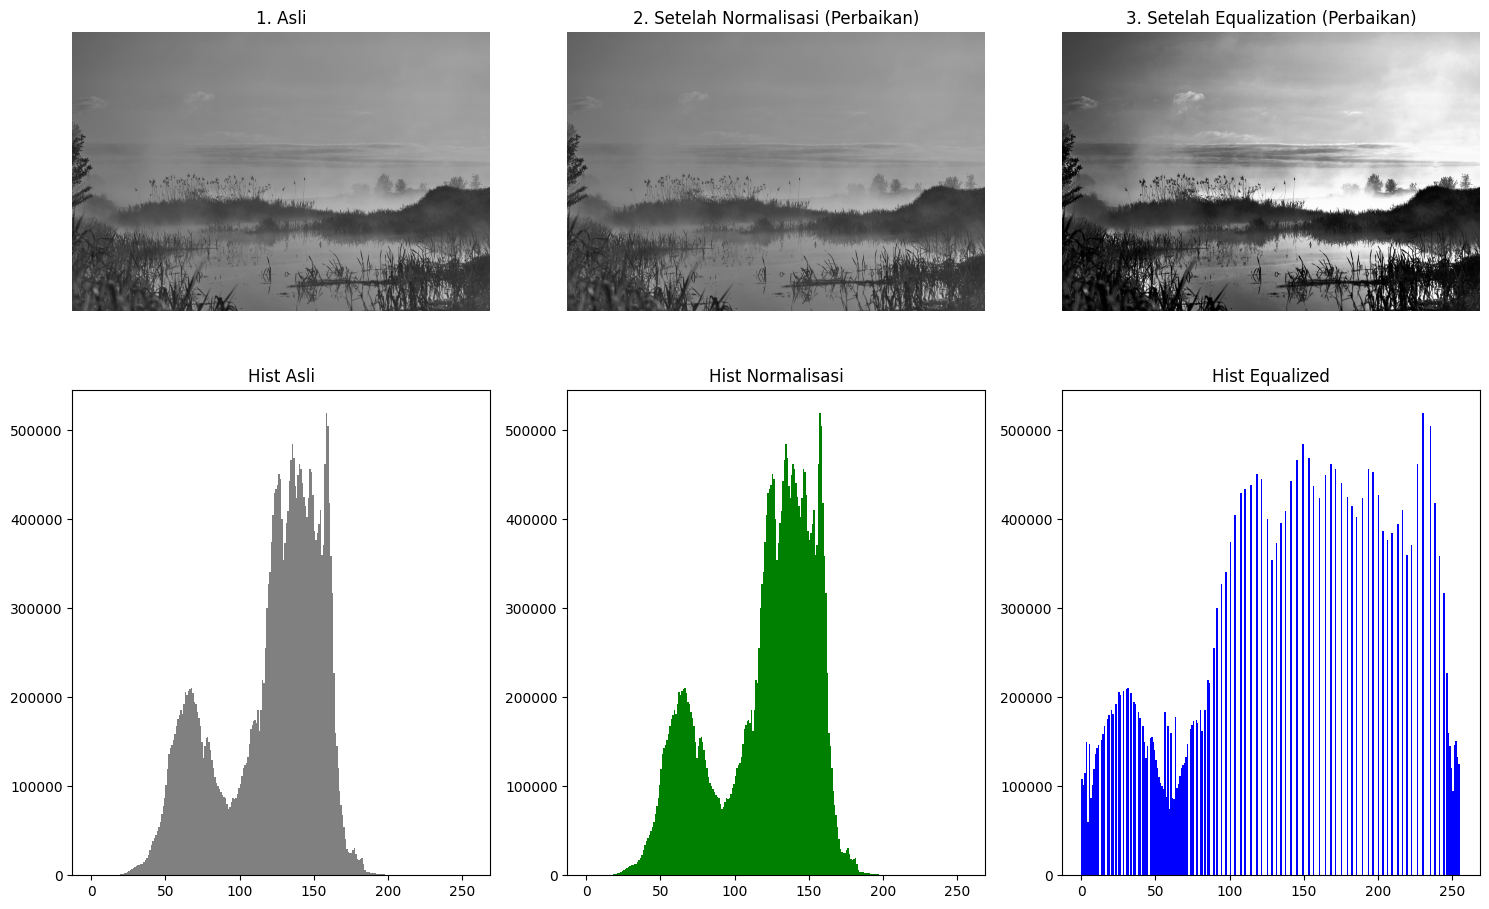

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca Citra (Grayscale)
# Ganti dengan path gambar Anda yang benar
img = cv2.imread('pemandangan.jpg', 0)

if img is None:
    print("Gambar tidak ditemukan! Pastikan path benar.")
else:
    # --- Ubah citra ke float32 untuk presisi ---
    img_f32 = img.astype('float32')

    # --- LANGKAH 1: MIN-MAX NORMALIZATION (Peregangan Kontras) ---
    img_min = np.min(img_f32)
    img_max = np.max(img_f32)

    # Lakukan perhitungan dalam float
    img_norm_f32 = (img_f32 - img_min) * 255.0 / (img_max - img_min)

    # ubah ke uint8 untuk hasil akhir Normalisasi
    img_norm = img_norm_f32.astype('uint8')

    # --- LANGKAH 2: HISTOGRAM EQUALIZATION (Pemerataan) ---
    # a. Hitung Histogram dari gambar yang sudah dinormalisasi (uint8)
    hist, bins = np.histogram(img_norm.flatten(), 256, [0, 256])

    # b. Hitung CDF (Cumulative Distribution Function)
    cdf = hist.cumsum()

    # c. Normalisasi CDF ke rentang 0-255 (Tetap gunakan float saat menghitung)
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255.0 / (cdf_m.max() - cdf_m.min()) # .0 memaksa float
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

    # d. Mapping hasil akhir
    img_equalized = cdf_final[img_norm]

    # --- VISUALISASI PERBANDINGAN ---
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    # Baris 1: Citra
    axs[0, 0].imshow(img, cmap='gray'); axs[0, 0].set_title('1. Asli')
    axs[0, 1].imshow(img_norm, cmap='gray'); axs[0, 1].set_title('2. Setelah Normalisasi (Perbaikan)')
    axs[0, 2].imshow(img_equalized, cmap='gray'); axs[0, 2].set_title('3. Setelah Equalization (Perbaikan)')

    # Baris 2: Histogram
    axs[1, 0].hist(img.ravel(), 256, [0, 256], color='gray'); axs[1, 0].set_title('Hist Asli')
    axs[1, 1].hist(img_norm.ravel(), 256, [0, 256], color='green'); axs[1, 1].set_title('Hist Normalisasi')
    axs[1, 2].hist(img_equalized.ravel(), 256, [0, 256], color='blue'); axs[1, 2].set_title('Hist Equalized')


    for ax in axs[0]: ax.axis('off')
    plt.tight_layout()
    plt.show()